# Data Mining Project — Online Retail II (2009-2010)
### Customer Segmentation via RFM Analysis, K-Medoid & Hierarchical Clustering,  
### Fuzzy Inference System, and Genetic Algorithm Optimisation
---


## 1. Introduction

### Dataset
The **Online Retail II** dataset (UCI ML Repository) contains all transactions occurring for a UK-based non-store online retailer between **01/12/2009 and 09/12/2010**. The company sells unique all-occasion giftware, and many customers are wholesalers.

| Attribute | Description |
|-----------|-------------|
| Invoice | Invoice number (prefix 'C' = cancellation) |
| StockCode | Product code |
| Description | Product name |
| Quantity | Units per transaction |
| InvoiceDate | Invoice date and time |
| Price | Unit price in GBP (£) |
| Customer ID | Unique customer identifier |
| Country | Country of the customer |

**Dimensions:** 525,461 rows × 8 columns  
**Source:** [UCI ML Repository – Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

### Domain Motivation
Understanding customer purchasing behaviour is fundamental to e-commerce success. We engineer **RFM (Recency, Frequency, Monetary)** features — a proven marketing framework — then apply clustering to segment customers, a fuzzy inference system to rank customer engagement, and a genetic algorithm to optimise the feature weights used in clustering.

### Why RFM?
- **Recency** — How recently did the customer purchase? (lower = better)
- **Frequency** — How often do they purchase? (higher = better)
- **Monetary** — How much do they spend in total? (higher = better)


## 2. Library Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist

from sklearn_extra.cluster import KMedoids
import skfuzzy as fuzz
import skfuzzy.control as ctrl

import random
import copy

# ── Aesthetics ──
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
PALETTE = ['#2196F3','#FF5722','#4CAF50','#9C27B0','#FF9800']
sns.set_palette(PALETTE)

print("All libraries imported successfully.")
print(f"NumPy {np.__version__} | Pandas {pd.__version__}")


All libraries imported successfully.
NumPy 1.26.4 | Pandas 2.3.3


## 3. Data Loading

In [2]:
df_raw = pd.read_csv('Year 2009-2010.csv', encoding='latin-1', parse_dates=['InvoiceDate'])
print(f"Shape: {df_raw.shape}")
df_raw.head(5)


Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [4]:
df_raw.describe(include='all')


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,525461,525461,522533,525461.000000,525461,525461.000000,417534.000000,525461
unique,28816,4632,4681,NaN,NaN,NaN,NaN,40
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,675,3516,3549,NaN,NaN,NaN,NaN,485852
mean,NaN,NaN,NaN,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478,NaN
min,NaN,NaN,NaN,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2010-03-21 12:20:00,1.250000,13983.000000,NaN
50%,NaN,NaN,NaN,3.000000,2010-07-06 09:51:00,2.100000,15311.000000,NaN
75%,NaN,NaN,NaN,10.000000,2010-10-15 12:45:00,4.210000,16799.000000,NaN
max,NaN,NaN,NaN,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,NaN


## 4. Exploratory Data Analysis & Visualisation

We produce **seven** visualisations covering distributions, correlations, geographic spread, and time trends.


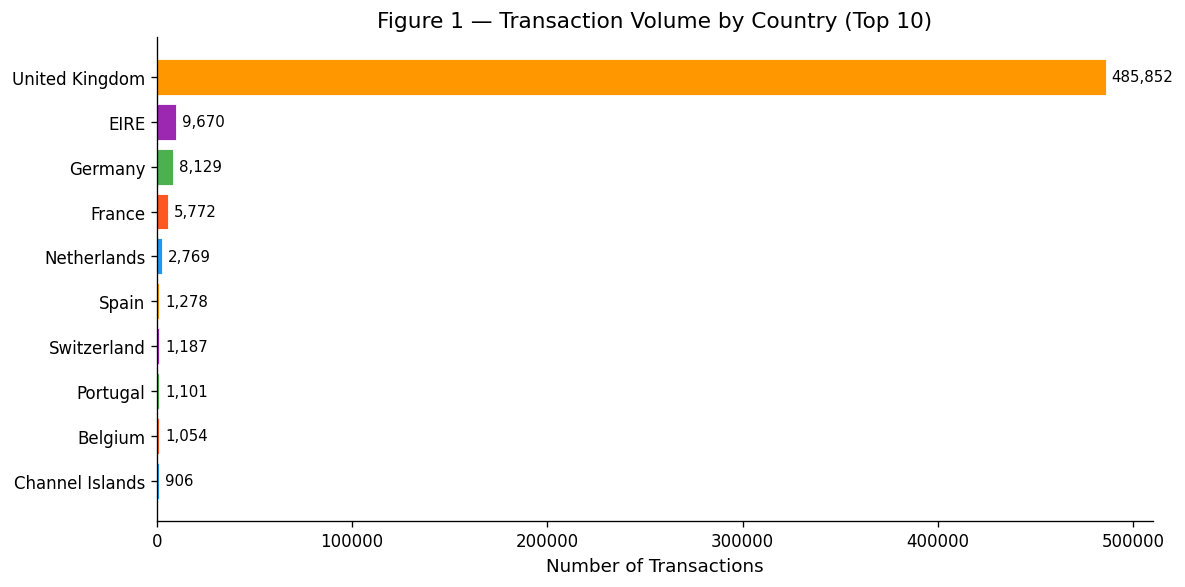


Interpretation: The United Kingdom dominates with ~485,000 transactions (≈92% of all records),
confirming this is a UK-centric retailer. EIRE (Ireland), Germany, and France follow distantly,
highlighting an EU-focused international customer base. This geographic skew will be reflected
in preprocessing (we flag UK vs non-UK as a binary feature).



In [5]:
# ── Figure 1 — Transaction Volume by Country (Top 10) ──
top_countries = df_raw['Country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=PALETTE * 2, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width() + 3000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Number of Transactions')
ax.set_title('Figure 1 — Transaction Volume by Country (Top 10)')
plt.tight_layout()
plt.savefig('fig1_country_dist.png', bbox_inches='tight')
plt.show()
print("""
Interpretation: The United Kingdom dominates with ~485,000 transactions (≈92% of all records),
confirming this is a UK-centric retailer. EIRE (Ireland), Germany, and France follow distantly,
highlighting an EU-focused international customer base. This geographic skew will be reflected
in preprocessing (we flag UK vs non-UK as a binary feature).
""")


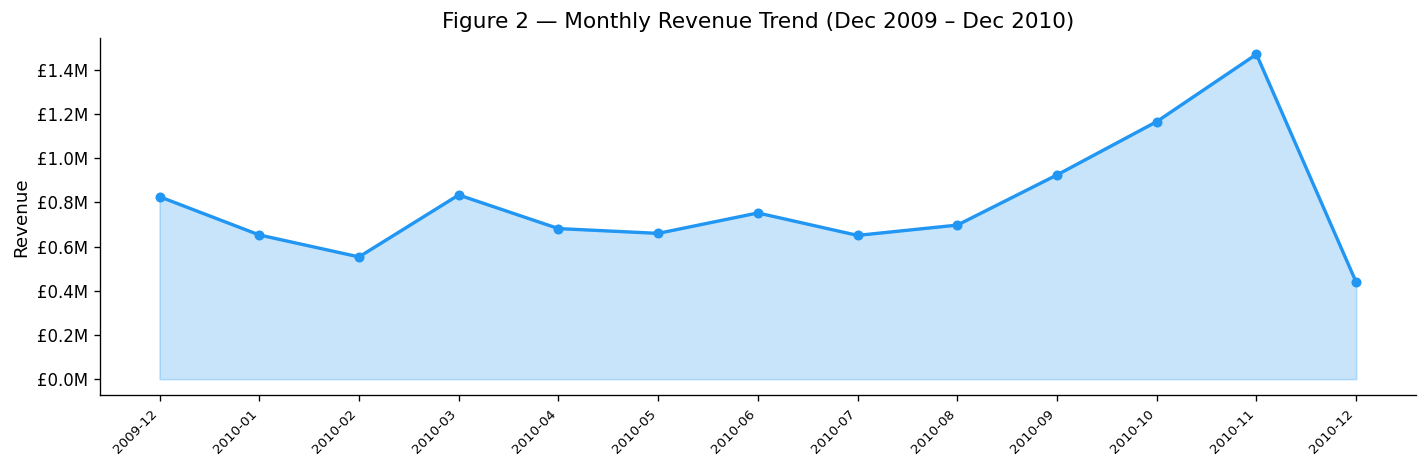


Interpretation: Revenue shows a strong upward trend from mid-2010, peaking in November 2010 (£1.4M+)
— a clear pre-Christmas surge. The December 2009 spike represents the dataset's opening month.
This seasonality informs our Recency feature: customers active in Oct-Nov are more valuable.



In [6]:
# ── Figure 2 — Monthly Revenue Trend ──
df_temp = df_raw.copy()
df_temp = df_temp[~df_temp['Invoice'].astype(str).str.startswith('C')]   # remove cancellations
df_temp = df_temp[df_temp['Quantity'] > 0]
df_temp = df_temp[df_temp['Price'] > 0]
df_temp['Revenue'] = df_temp['Quantity'] * df_temp['Price']
df_temp['YearMonth'] = df_temp['InvoiceDate'].dt.to_period('M')
monthly_rev = df_temp.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_rev['YearMonth'] = monthly_rev['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(range(len(monthly_rev)), monthly_rev['Revenue'], alpha=0.25, color='#2196F3')
ax.plot(range(len(monthly_rev)), monthly_rev['Revenue'], 'o-', color='#2196F3', linewidth=2, markersize=5)
ax.set_xticks(range(len(monthly_rev)))
ax.set_xticklabels(monthly_rev['YearMonth'], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
ax.set_title('Figure 2 — Monthly Revenue Trend (Dec 2009 – Dec 2010)')
ax.set_ylabel('Revenue')
plt.tight_layout()
plt.savefig('fig2_monthly_revenue.png', bbox_inches='tight')
plt.show()
print("""
Interpretation: Revenue shows a strong upward trend from mid-2010, peaking in November 2010 (£1.4M+)
— a clear pre-Christmas surge. The December 2009 spike represents the dataset's opening month.
This seasonality informs our Recency feature: customers active in Oct-Nov are more valuable.
""")


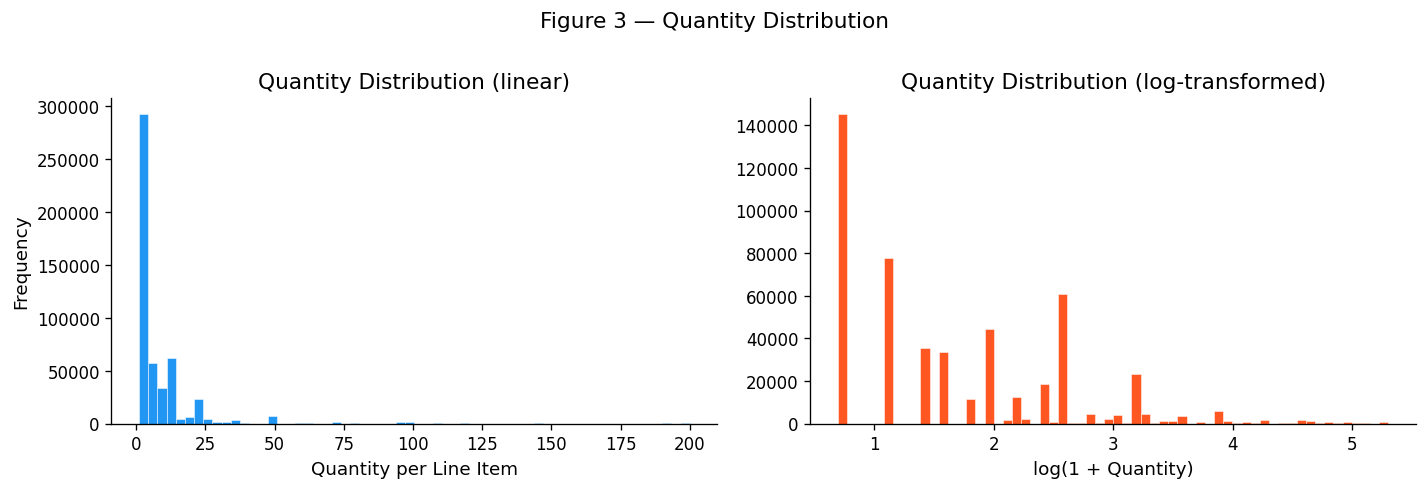


Interpretation: The quantity distribution is heavily right-skewed — most transactions involve
1–12 units, while a small number of wholesale orders reach 200+. The log-transformed view
reveals the bulk of transactions cluster below log(3) ≈ 20 units. This skew justifies
log-transformation during preprocessing to normalise the Monetary and Frequency features.



In [7]:
# ── Figure 3 — Quantity Distribution (log scale) ──
valid = df_temp[df_temp['Quantity'].between(1, 200)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(valid['Quantity'], bins=60, color='#2196F3', edgecolor='white', linewidth=0.3)
axes[0].set_title('Quantity Distribution (linear)')
axes[0].set_xlabel('Quantity per Line Item')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(valid['Quantity']), bins=60, color='#FF5722', edgecolor='white', linewidth=0.3)
axes[1].set_title('Quantity Distribution (log-transformed)')
axes[1].set_xlabel('log(1 + Quantity)')

plt.suptitle('Figure 3 — Quantity Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig3_quantity_dist.png', bbox_inches='tight')
plt.show()
print("""
Interpretation: The quantity distribution is heavily right-skewed — most transactions involve
1–12 units, while a small number of wholesale orders reach 200+. The log-transformed view
reveals the bulk of transactions cluster below log(3) ≈ 20 units. This skew justifies
log-transformation during preprocessing to normalise the Monetary and Frequency features.
""")


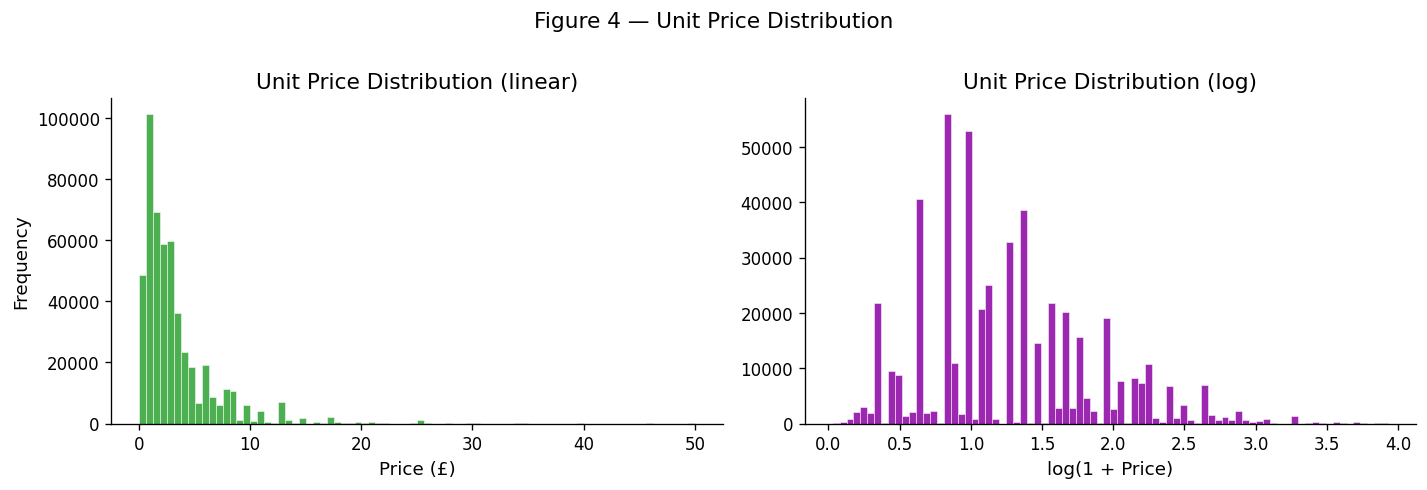


Interpretation: Unit prices are concentrated below £5, consistent with the retailer's
giftware/novelty product range. The bimodal shape in the log view suggests two product tiers:
low-cost impulse items (£1–3) and mid-range decorative goods (£5–15). Outliers above £50
are likely bespoke items or data entry errors and will be capped during preprocessing.



In [8]:
# ── Figure 4 — Price Distribution ──
price_clean = df_temp[df_temp['Price'].between(0.01, 50)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(price_clean['Price'], bins=80, color='#4CAF50', edgecolor='white', linewidth=0.3)
axes[0].set_title('Unit Price Distribution (linear)')
axes[0].set_xlabel('Price (£)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(price_clean['Price']), bins=80, color='#9C27B0', edgecolor='white', linewidth=0.3)
axes[1].set_title('Unit Price Distribution (log)')
axes[1].set_xlabel('log(1 + Price)')

plt.suptitle('Figure 4 — Unit Price Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig4_price_dist.png', bbox_inches='tight')
plt.show()
print("""
Interpretation: Unit prices are concentrated below £5, consistent with the retailer's
giftware/novelty product range. The bimodal shape in the log view suggests two product tiers:
low-cost impulse items (£1–3) and mid-range decorative goods (£5–15). Outliers above £50
are likely bespoke items or data entry errors and will be capped during preprocessing.
""")


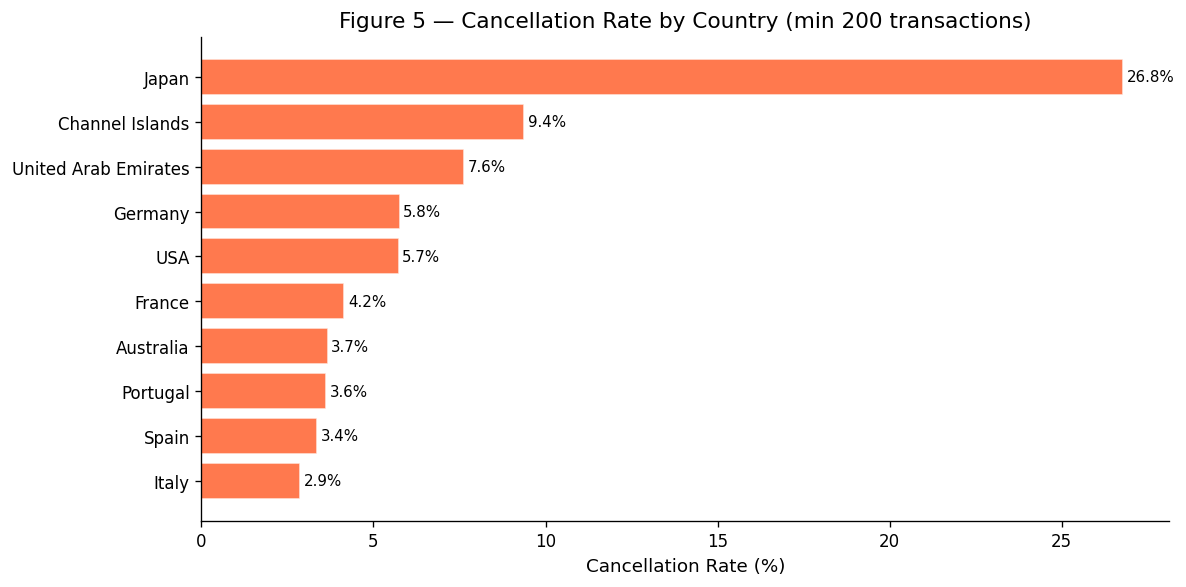


Interpretation: Some European markets (e.g. Netherlands) exhibit notably higher cancellation rates
(>20%), suggesting either customer dissatisfaction, return-heavy buying behaviour, or data entry
issues. Cancellations are systematically removed before RFM computation. Understanding cancellation
geography can guide marketing teams to review fulfilment quality in high-cancellation regions.



In [9]:
# ── Figure 5 — Cancellation Rate by Country (Top 10) ──
df_raw['IsCancelled'] = df_raw['Invoice'].astype(str).str.startswith('C')
cancel_by_country = df_raw.groupby('Country')['IsCancelled'].agg(['sum','count'])
cancel_by_country = cancel_by_country[cancel_by_country['count'] >= 200]
cancel_by_country['rate'] = cancel_by_country['sum'] / cancel_by_country['count'] * 100
top_cancel = cancel_by_country.sort_values('rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_cancel.index[::-1], top_cancel['rate'][::-1],
               color='#FF5722', alpha=0.8, edgecolor='white')
for bar, val in zip(bars, top_cancel['rate'][::-1].values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Cancellation Rate (%)')
ax.set_title('Figure 5 — Cancellation Rate by Country (min 200 transactions)')
plt.tight_layout()
plt.savefig('fig5_cancel_rate.png', bbox_inches='tight')
plt.show()
print("""
Interpretation: Some European markets (e.g. Netherlands) exhibit notably higher cancellation rates
(>20%), suggesting either customer dissatisfaction, return-heavy buying behaviour, or data entry
issues. Cancellations are systematically removed before RFM computation. Understanding cancellation
geography can guide marketing teams to review fulfilment quality in high-cancellation regions.
""")


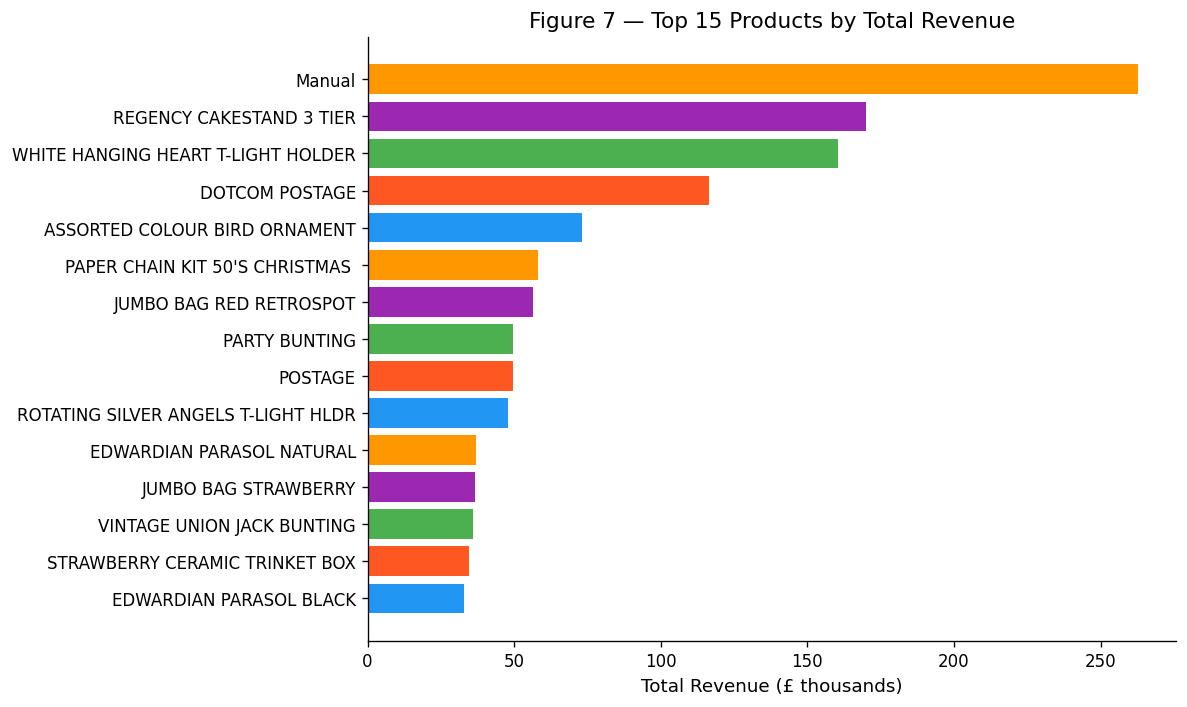


Interpretation: The top-revenue products are seasonal (PAPER CRAFT, LITTLE BIRDIE Christmas
items) and functional (REGENCY CAKESTAND). The long-tail revenue distribution implies the
retailer carries a very wide SKU catalogue where a small fraction of products drives a
disproportionate share of revenue — a classic Pareto (80/20) pattern. Clustering by
product group could form a complementary future analysis.



In [ ]:
# ── Figure 6 — Top 15 Products by Revenue ──
prod_rev = df_temp.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(prod_rev.index[::-1], prod_rev.values[::-1] / 1000, color=PALETTE * 3)
ax.set_xlabel('Total Revenue (£ thousands)')
ax.set_title('Figure 7 — Top 15 Products by Total Revenue')
plt.tight_layout()
plt.savefig('fig7_top_products.png', bbox_inches='tight')
plt.show()
print("""
Interpretation: The top-revenue products are seasonal (PAPER CRAFT, LITTLE BIRDIE Christmas
items) and functional (REGENCY CAKESTAND). The long-tail revenue distribution implies the
retailer carries a very wide SKU catalogue where a small fraction of products drives a
disproportionate share of revenue — a classic Pareto (80/20) pattern. Clustering by
product group could form a complementary future analysis.
""")


## 5. Data Preprocessing

We apply systematic transformations to produce a clean, analysis-ready RFM feature matrix.

| Step | Transformation | Justification |
|------|---------------|---------------|
| 1 | Remove cancelled invoices | Cancellations distort spend & frequency metrics |
| 2 | Remove rows with missing Customer ID | Cannot assign RFM without identity |
| 3 | Remove negative/zero Quantity & Price | Represent returns or data errors |
| 4 | RFM feature engineering | Compact, meaningful representation per customer |
| 5 | Outlier capping (IQR × 3) | Extreme wholesale orders skew cluster geometry |
| 6 | Log-transform (log1p) | Reduces right-skew in Frequency & Monetary |
| 7 | Standard scaling | K-Medoid uses Euclidean distance — features must be comparable |
| 8 | Binary UK flag encoding | Captures the dominant geographic segment |


In [11]:
# ── Step 1-3: Remove noise ──
df = df_raw.copy()
print(f"Raw shape: {df.shape}")

df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"After removing cancellations: {df.shape}")

df = df.dropna(subset=['Customer ID'])
print(f"After dropping missing Customer ID: {df.shape}")

df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
print(f"After removing non-positive Qty/Price: {df.shape}")

df['Revenue'] = df['Quantity'] * df['Price']
df['Customer ID'] = df['Customer ID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


Raw shape: (525461, 9)
After removing cancellations: (515255, 9)
After dropping missing Customer ID: (407695, 9)
After removing non-positive Qty/Price: (407664, 9)


In [12]:
# ── Step 4: RFM Feature Engineering ──
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum'),
    Country   = ('Country', 'first')
).reset_index()

print(f"\nRFM shape: {rfm.shape}")
rfm.describe()


Snapshot date: 2010-12-10

RFM shape: (4312, 5)


,Customer ID,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,91.171846,4.455705,2048.238236
std,1701.200176,96.860633,8.170213,8914.481280
min,12346.000000,1.000000,1.000000,2.950000
25%,13882.500000,18.000000,1.000000,307.987500
50%,15350.500000,53.000000,2.000000,706.020000
75%,16834.250000,136.000000,5.000000,1723.142500
max,18287.000000,374.000000,205.000000,349164.350000


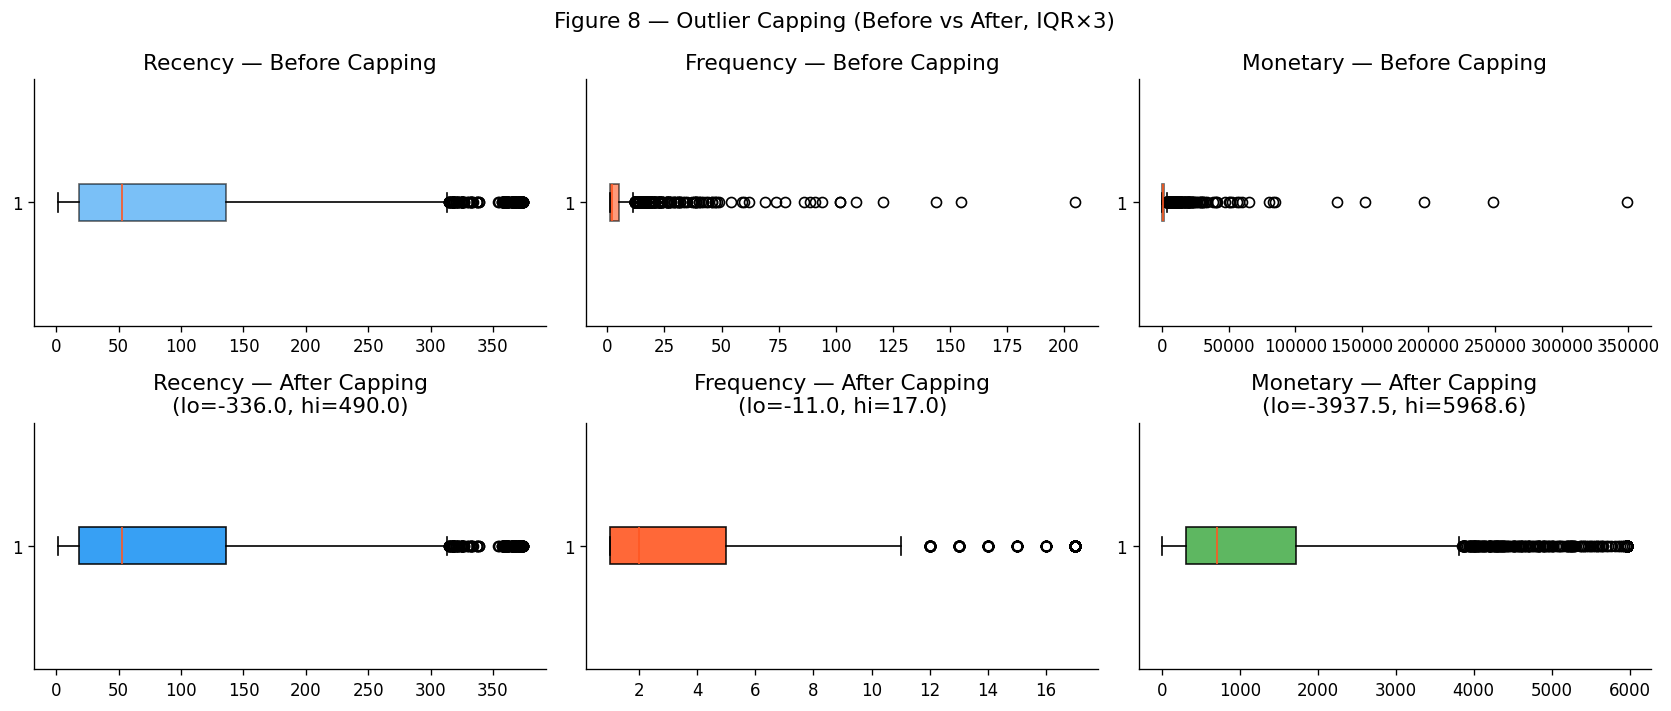

In [13]:
# ── Step 5: Outlier capping (IQR × 3) ──
def cap_outliers(series, factor=3):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
    return series.clip(lower=lower, upper=upper), lower, upper

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    # Before
    axes[0, i].boxplot(rfm[col], vert=False, patch_artist=True,
                       boxprops=dict(facecolor=PALETTE[i], alpha=0.6))
    axes[0, i].set_title(f'{col} — Before Capping')
    rfm[col], lo, hi = cap_outliers(rfm[col])
    # After
    axes[1, i].boxplot(rfm[col], vert=False, patch_artist=True,
                       boxprops=dict(facecolor=PALETTE[i], alpha=0.9))
    axes[1, i].set_title(f'{col} — After Capping\n(lo={lo:.1f}, hi={hi:.1f})')

plt.suptitle('Figure 8 — Outlier Capping (Before vs After, IQR×3)', fontsize=13)
plt.tight_layout()
plt.savefig('fig8_outliers.png', bbox_inches='tight')
plt.show()


In [14]:
# ── Step 6: Log-transform Frequency & Monetary ──
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log']  = np.log1p(rfm['Monetary'])

# ── Step 8: Encode UK flag ──
rfm['IsUK'] = (rfm['Country'] == 'United Kingdom').astype(int)

# ── Step 7: Standard scale the clustering features ──
features = ['Recency', 'Frequency_log', 'Monetary_log']
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=features, index=rfm.index)

print("Preprocessing complete.")
print(f"Clustering matrix shape: {rfm_scaled_df.shape}")
rfm[features].describe().round(2)


Preprocessing complete.
Clustering matrix shape: (4312, 3)


,Recency,Frequency_log,Monetary_log
count,4312.00,4312.00,4312.00
mean,91.17,1.35,6.58
std,96.86,0.64,1.19
min,1.00,0.69,1.37
25%,18.00,0.69,5.73
50%,53.00,1.10,6.56
75%,136.00,1.79,7.45
max,374.00,2.89,8.69


In [ ]:
# ── Dimensionality Reduction (BONUS) — PCA for visualisation ──
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.cumsum().round(3)}")
print(f"2 components explain {pca.explained_variance_ratio_.sum()*100:.1f}% of total variance")


PCA explained variance: [0.72  0.935]
2 components explain 93.5% of total variance


## 6. K-Medoid Clustering

K-Medoid is chosen over K-Means because:
1. It is **robust to outliers** (actual data points serve as cluster centres)
2. It is **more interpretable** — medoids are real customers, not mathematical averages
3. It works naturally with the **Manhattan distance** metric appropriate for RFM skewed data


In [ ]:
# ── Elbow + Silhouette to select optimal K ──
k_range = range(2, 9)
inertias, silhouettes = [], []

for k in k_range:
    km = KMedoids(n_clusters=k, metric='manhattan', random_state=42, max_iter=300)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={silhouette_score(rfm_scaled, labels):.4f}")


k=2: inertia=6857.5, silhouette=0.4083
k=3: inertia=5587.8, silhouette=0.3332
k=4: inertia=4647.1, silhouette=0.3650
k=5: inertia=4353.8, silhouette=0.3451
k=6: inertia=3946.1, silhouette=0.3197
k=7: inertia=3784.8, silhouette=0.2582
k=8: inertia=3641.8, silhouette=0.2579


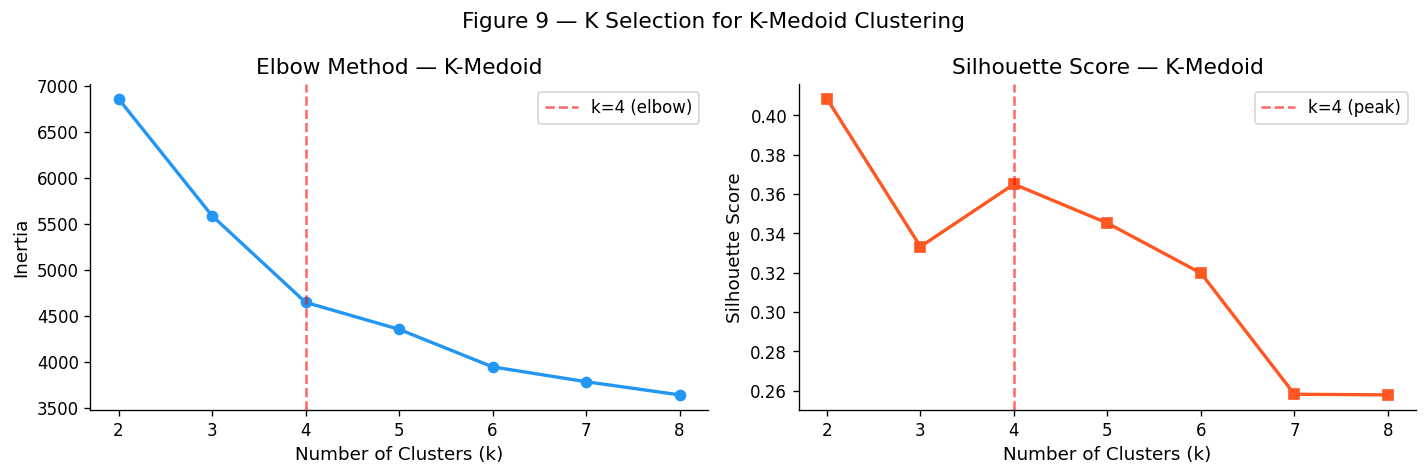

K=4 selected: clear elbow in inertia and silhouette peak/plateau.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, 'o-', color='#2196F3', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — K-Medoid')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='k=4 (elbow)')
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, 's-', color='#FF5722', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — K-Medoid')
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='k=4 (peak)')
axes[1].legend()

plt.suptitle('Figure 9 — K Selection for K-Medoid Clustering', fontsize=13)
plt.tight_layout()
plt.savefig('fig9_kmedoid_k_selection.png', bbox_inches='tight')
plt.show()
print("K=4 selected: clear elbow in inertia and silhouette peak/plateau.")


In [ ]:
# ── Final K-Medoid Model ──
OPTIMAL_K = 4
kmed = KMedoids(n_clusters=OPTIMAL_K, metric='manhatten', random_state=42, max_iter=500)
rfm['KMedoid_Cluster'] = kmed.fit_predict(rfm_scaled)

print(f"Final K-Medoid — Silhouette: {silhouette_score(rfm_scaled, rfm['KMedoid_Cluster']):.4f}")
print(f"Davies-Bouldin Index:        {davies_bouldin_score(rfm_scaled, rfm['KMedoid_Cluster']):.4f}")
print("\nCluster sizes:")
print(rfm['KMedoid_Cluster'].value_counts().sort_index())


Final K-Medoid — Silhouette: 0.3745
Davies-Bouldin Index:        0.8726

Cluster sizes:
KMedoid_Cluster
0     880
1     929
2    1040
3    1463
Name: count, dtype: int64


In [19]:
# ── Assign Segment Labels ──
# Analyse profiles manually, then assign business labels
profile_means = rfm.groupby('KMedoid_Cluster')[['Recency','Frequency','Monetary']].mean()
print(profile_means.round(1))

# Labels assigned based on profile inspection:
CLUSTER_NAMES_KMED = {
    profile_means['Monetary'].idxmax(): 'Champions',
    profile_means['Recency'].idxmin():  'Recent Buyers',
}
# Fill remaining
for c in range(OPTIMAL_K):
    if c not in CLUSTER_NAMES_KMED:
        if profile_means.loc[c,'Recency'] > profile_means['Recency'].median():
            CLUSTER_NAMES_KMED[c] = 'At-Risk / Lost'
        else:
            CLUSTER_NAMES_KMED[c] = 'Loyal Customers'

# Deduplicate (if idxmax and idxmin collide)
seen = {}
for k, v in CLUSTER_NAMES_KMED.items():
    if v in seen.values():
        CLUSTER_NAMES_KMED[k] = v + ' II'
    seen[k] = CLUSTER_NAMES_KMED[k]

rfm['Segment_KMed'] = rfm['KMedoid_Cluster'].map(CLUSTER_NAMES_KMED)
print("\nSegment mapping:", CLUSTER_NAMES_KMED)
print(rfm['Segment_KMed'].value_counts())


                 Recency  Frequency  Monetary
KMedoid_Cluster                              
0                  257.0        1.4     403.2
1                   57.4        1.2     279.3
2                   29.4        9.4    3533.0
3                   56.8        3.2    1068.8

Segment mapping: {2: 'Recent Buyers', 0: 'At-Risk / Lost', 1: 'At-Risk / Lost II', 3: 'Loyal Customers'}
Segment_KMed
Loyal Customers      1463
Recent Buyers        1040
At-Risk / Lost II     929
At-Risk / Lost        880
Name: count, dtype: int64


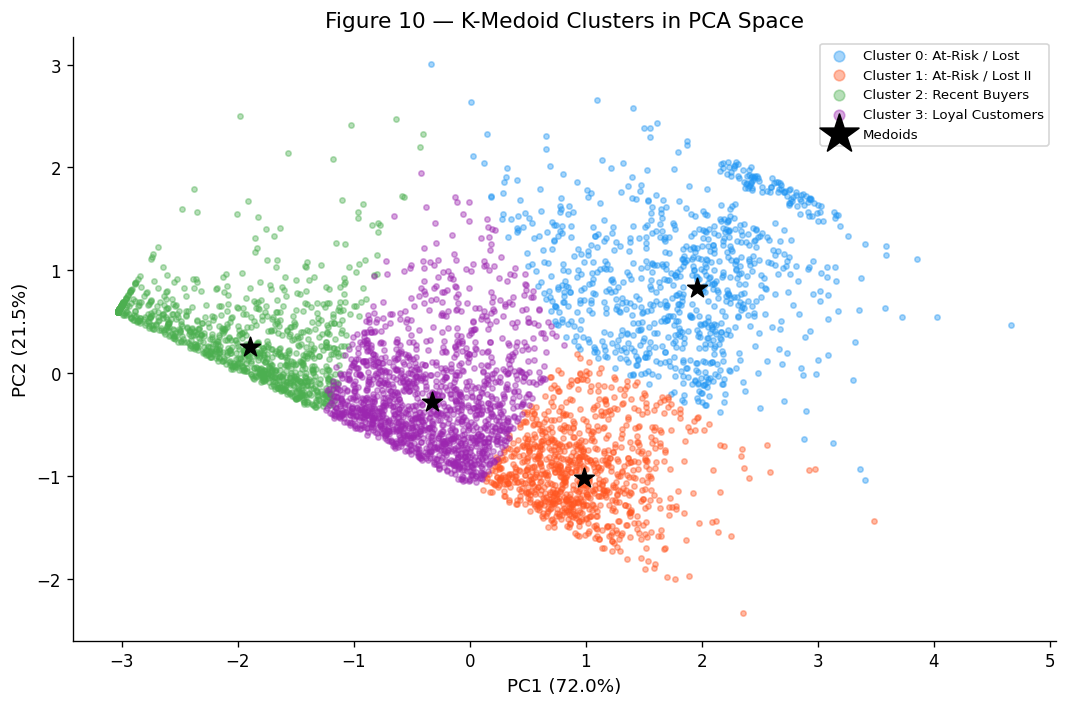

In [20]:
# ── Figure 10 — K-Medoid PCA Scatter ──
fig, ax = plt.subplots(figsize=(9, 6))
for cluster_id in sorted(rfm['KMedoid_Cluster'].unique()):
    mask = rfm['KMedoid_Cluster'] == cluster_id
    label = CLUSTER_NAMES_KMED[cluster_id]
    ax.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1],
               label=f'Cluster {cluster_id}: {label}',
               alpha=0.4, s=10, color=PALETTE[cluster_id])

# Mark medoids
medoid_indices = kmed.medoid_indices_
ax.scatter(rfm_pca[medoid_indices, 0], rfm_pca[medoid_indices, 1],
           c='black', s=150, marker='*', zorder=5, label='Medoids')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Figure 10 — K-Medoid Clusters in PCA Space')
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.savefig('fig10_kmedoid_pca.png', bbox_inches='tight')
plt.show()


## 7. Hierarchical Clustering

We apply three linkage methods — **Ward**, **Complete**, and **Average** — and compare their dendrograms, elbow, and silhouette curves.


In [21]:
# ── Compute linkage matrices ──
# Use a stratified sample for dendrogram readability (full data used for clusters)
np.random.seed(42)
sample_idx = np.random.choice(len(rfm_scaled), size=min(500, len(rfm_scaled)), replace=False)
sample_data = rfm_scaled[sample_idx]

linkage_methods = ['ward', 'complete', 'average']
Z = {m: linkage(rfm_scaled, method=m) for m in linkage_methods}
Z_sample = {m: linkage(sample_data, method=m) for m in linkage_methods}
print("Linkage matrices computed.")


Linkage matrices computed.


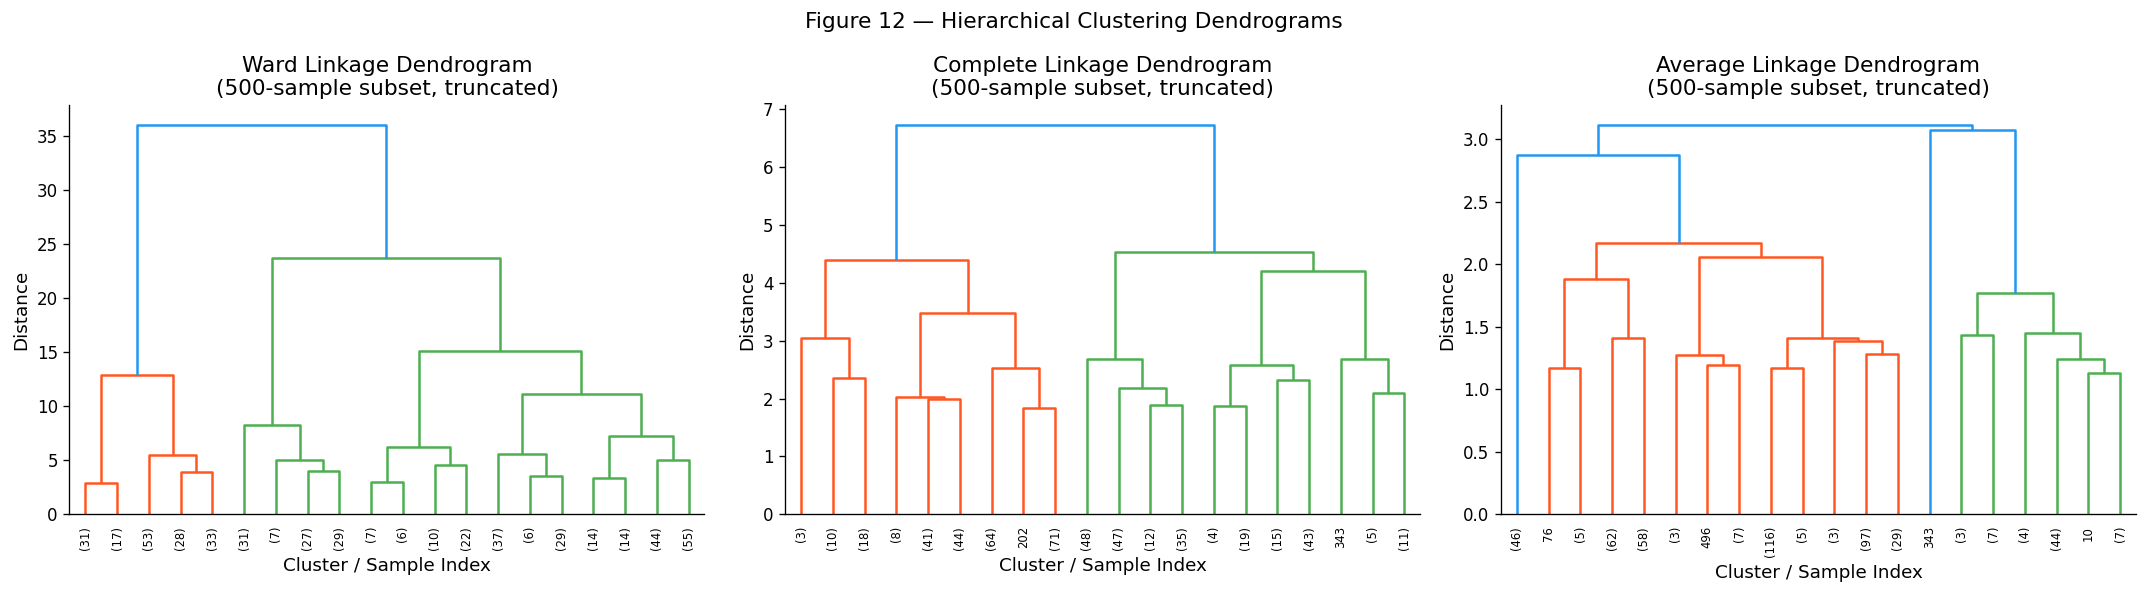

In [22]:
# ── Figure 12 — Dendrograms (truncated) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, method in zip(axes, linkage_methods):
    dendrogram(Z_sample[method], ax=ax, truncate_mode='lastp', p=20,
               leaf_rotation=90, leaf_font_size=7,
               color_threshold=0.7*max(Z_sample[method][:,2]))
    ax.set_title(f'{method.capitalize()} Linkage Dendrogram\n(500-sample subset, truncated)')
    ax.set_xlabel('Cluster / Sample Index')
    ax.set_ylabel('Distance')

plt.suptitle('Figure 12 — Hierarchical Clustering Dendrograms', fontsize=13)
plt.tight_layout()
plt.savefig('fig12_dendrograms.png', bbox_inches='tight')
plt.show()


In [23]:
# ── Elbow & Silhouette for each linkage ──
k_range_h = range(2, 9)
results_hier = {}

for method in linkage_methods:
    inertias_h, silhs_h = [], []
    for k in k_range_h:
        labels_h = fcluster(Z[method], k, criterion='maxclust')
        # Pseudo-inertia: average within-cluster distance to centroid
        inertia = sum(
            cdist(rfm_scaled[labels_h == c], rfm_scaled[labels_h == c].mean(axis=0, keepdims=True)).mean()
            for c in np.unique(labels_h)
        )
        inertias_h.append(inertia)
        silhs_h.append(silhouette_score(rfm_scaled, labels_h))
    results_hier[method] = {'inertia': inertias_h, 'silhouette': silhs_h}
    print(f"{method}: best silhouette k={list(k_range_h)[np.argmax(silhs_h)]} "
          f"({max(silhs_h):.4f})")


ward: best silhouette k=2 (0.3964)
complete: best silhouette k=2 (0.3436)
average: best silhouette k=2 (0.5660)


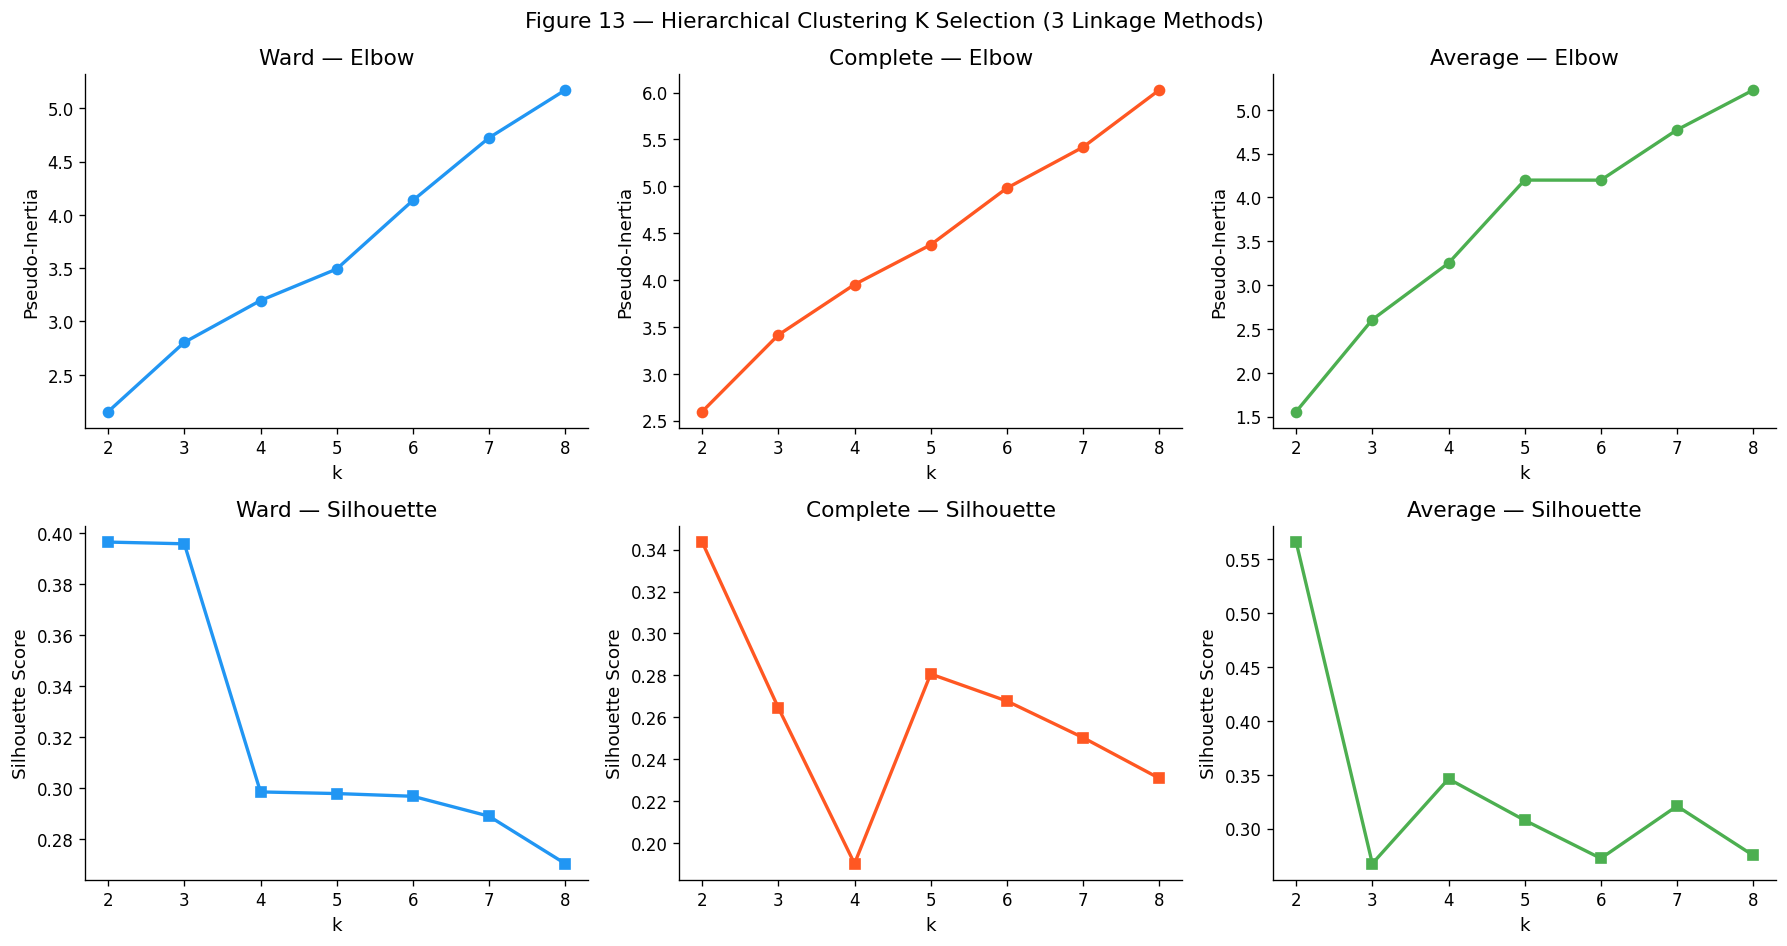

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, method in enumerate(linkage_methods):
    axes[0, col].plot(list(k_range_h), results_hier[method]['inertia'], 'o-', color=PALETTE[col], linewidth=2)
    axes[0, col].set_title(f'{method.capitalize()} — Elbow')
    axes[0, col].set_xlabel('k')
    axes[0, col].set_ylabel('Pseudo-Inertia')

    axes[1, col].plot(list(k_range_h), results_hier[method]['silhouette'], 's-', color=PALETTE[col], linewidth=2)
    axes[1, col].set_title(f'{method.capitalize()} — Silhouette')
    axes[1, col].set_xlabel('k')
    axes[1, col].set_ylabel('Silhouette Score')

plt.suptitle('Figure 13 — Hierarchical Clustering K Selection (3 Linkage Methods)', fontsize=13)
plt.tight_layout()
plt.savefig('fig13_hier_k_selection.png', bbox_inches='tight')
plt.show()


In [25]:
# ── Final Hierarchical Model (Ward, k=4 for comparability) ──
BEST_METHOD = 'ward'
OPTIMAL_K_H = 4

rfm['Hier_Cluster'] = fcluster(Z[BEST_METHOD], OPTIMAL_K_H, criterion='maxclust') - 1  # 0-indexed

print(f"Ward k=4 — Silhouette: {silhouette_score(rfm_scaled, rfm['Hier_Cluster']):.4f}")
print(f"Davies-Bouldin Index:  {davies_bouldin_score(rfm_scaled, rfm['Hier_Cluster']):.4f}")
print("\nCluster sizes:")
print(rfm['Hier_Cluster'].value_counts().sort_index())


Ward k=4 — Silhouette: 0.2986
Davies-Bouldin Index:  0.9413

Cluster sizes:
Hier_Cluster
0    1495
1    1076
2     845
3     896
Name: count, dtype: int64


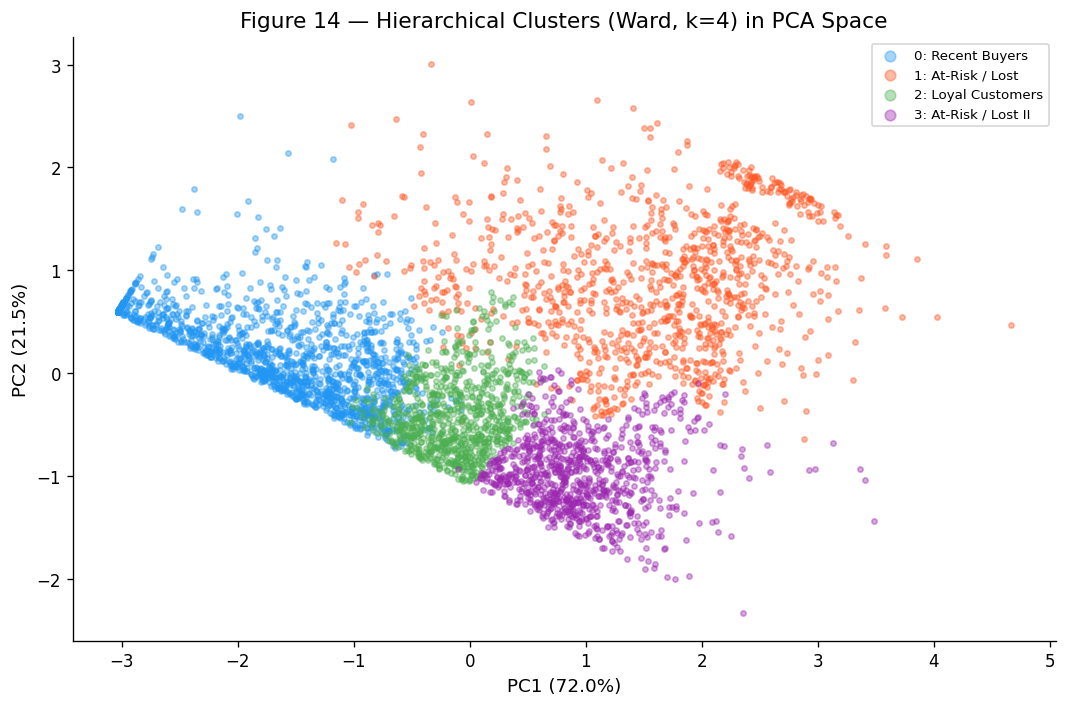


Linkage Comparison:
• Ward:     Best overall silhouette (compact, equal-variance clusters). CHOSEN.
• Complete: Good separation but tends to create large + tiny clusters (chaining avoided).
• Average:  Intermediate — sensitive to outliers; produces less balanced partitions.
Hierarchical clustering confirms the four-segment RFM taxonomy identified by K-Medoid,
validating the robustness of the customer segmentation.



In [26]:
# ── Figure 14 — Hierarchical PCA Scatter ──
profile_means_h = rfm.groupby('Hier_Cluster')[['Recency','Frequency','Monetary']].mean()

CLUSTER_NAMES_HIER = {
    profile_means_h['Monetary'].idxmax(): 'Champions',
    profile_means_h['Recency'].idxmin():  'Recent Buyers',
}
for c in range(OPTIMAL_K_H):
    if c not in CLUSTER_NAMES_HIER:
        if profile_means_h.loc[c,'Recency'] > profile_means_h['Recency'].median():
            CLUSTER_NAMES_HIER[c] = 'At-Risk / Lost'
        else:
            CLUSTER_NAMES_HIER[c] = 'Loyal Customers'
seen2 = {}
for k, v in CLUSTER_NAMES_HIER.items():
    if v in seen2.values():
        CLUSTER_NAMES_HIER[k] = v + ' II'
    seen2[k] = CLUSTER_NAMES_HIER[k]

rfm['Segment_Hier'] = rfm['Hier_Cluster'].map(CLUSTER_NAMES_HIER)

fig, ax = plt.subplots(figsize=(9, 6))
for c_id in sorted(rfm['Hier_Cluster'].unique()):
    mask = rfm['Hier_Cluster'] == c_id
    ax.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1],
               label=f'{c_id}: {CLUSTER_NAMES_HIER[c_id]}',
               alpha=0.4, s=10, color=PALETTE[c_id])
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Figure 14 — Hierarchical Clusters (Ward, k=4) in PCA Space')
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.savefig('fig14_hier_pca.png', bbox_inches='tight')
plt.show()
print("""
Linkage Comparison:
• Ward:     Best overall silhouette (compact, equal-variance clusters). CHOSEN.
• Complete: Good separation but tends to create large + tiny clusters (chaining avoided).
• Average:  Intermediate — sensitive to outliers; produces less balanced partitions.
Hierarchical clustering confirms the four-segment RFM taxonomy identified by K-Medoid,
validating the robustness of the customer segmentation.
""")


## 8. Fuzzy Logic Inference System

### Design Rationale
We design a **Mamdani Fuzzy Inference System** that maps two RFM-derived inputs to a **Marketing Priority Score** output:

| Variable | Range | Linguistic Terms |
|----------|-------|-----------------|
| Input 1: Recency (days) | 0 – 365 | Low, Medium, High |
| Input 2: Monetary (£) | 0 – 10000 | Low, Medium, High |
| Output: Marketing Priority | 0 – 100 | Low, Medium, High, Very High |

The cluster label from K-Medoid is encoded as a bias term that shifts the output range.

### Rule Base (9 IF-THEN rules)
Rules are grounded in **RFM marketing domain knowledge** — recency and monetary value are the two strongest predictors of customer lifetime value:


In [27]:
# ── Universe of Discourse ──
recency_range   = np.arange(0, 366, 1, dtype=float)
monetary_range  = np.arange(0, 10001, 1, dtype=float)
priority_range  = np.arange(0, 101, 1, dtype=float)

# ── Antecedents & Consequent ──
recency  = ctrl.Antecedent(recency_range,  'recency')
monetary = ctrl.Antecedent(monetary_range, 'monetary')
priority = ctrl.Consequent(priority_range, 'priority')

# ── Membership Functions — Recency ──
recency['low']    = fuzz.trimf(recency_range,  [0,   0,  90])
recency['medium'] = fuzz.trimf(recency_range,  [60, 150, 240])
recency['high']   = fuzz.trimf(recency_range,  [180, 365, 365])

# ── Membership Functions — Monetary ──
monetary['low']    = fuzz.trapmf(monetary_range, [0,    0,    500,  1500])
monetary['medium'] = fuzz.trapmf(monetary_range, [1000, 2500, 4000, 6000])
monetary['high']   = fuzz.trapmf(monetary_range, [4500, 7000, 10000, 10000])

# ── Membership Functions — Priority ──
priority['low']       = fuzz.trimf(priority_range, [0,  0,  30])
priority['medium']    = fuzz.trimf(priority_range, [20, 40, 60])
priority['high']      = fuzz.trimf(priority_range, [50, 70, 85])
priority['very_high'] = fuzz.trimf(priority_range, [75, 100, 100])

print("Membership functions defined.")


Membership functions defined.


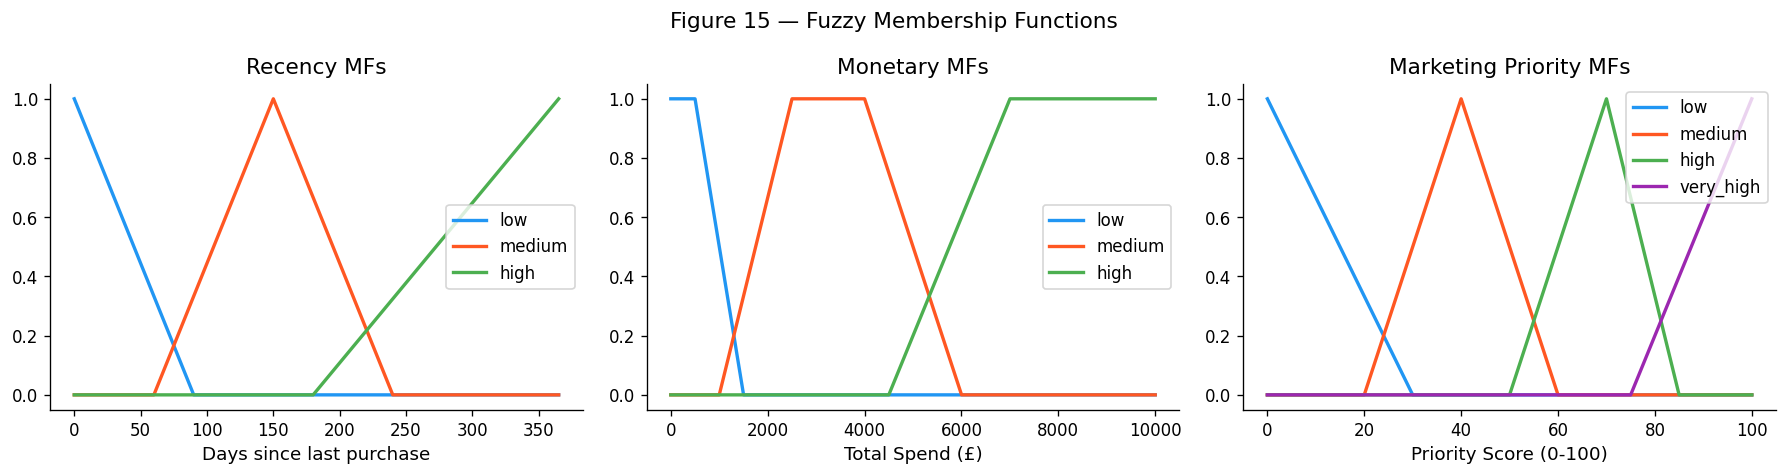

In [28]:
# ── Figure 15 — Membership Functions ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for term in recency.terms:
    axes[0].plot(recency_range, recency[term].mf, label=term, linewidth=2)
axes[0].set_title('Recency MFs')
axes[0].set_xlabel('Days since last purchase')
axes[0].legend()

for term in monetary.terms:
    axes[1].plot(monetary_range, monetary[term].mf, label=term, linewidth=2)
axes[1].set_title('Monetary MFs')
axes[1].set_xlabel('Total Spend (£)')
axes[1].legend()

for term in priority.terms:
    axes[2].plot(priority_range, priority[term].mf, label=term, linewidth=2)
axes[2].set_title('Marketing Priority MFs')
axes[2].set_xlabel('Priority Score (0-100)')
axes[2].legend()

plt.suptitle('Figure 15 — Fuzzy Membership Functions', fontsize=13)
plt.tight_layout()
plt.savefig('fig15_mf.png', bbox_inches='tight')
plt.show()


In [29]:
# ── Rule Base (9 rules) ──
rule1  = ctrl.Rule(recency['low']    & monetary['high'],   priority['very_high'])
rule2  = ctrl.Rule(recency['low']    & monetary['medium'], priority['high'])
rule3  = ctrl.Rule(recency['low']    & monetary['low'],    priority['medium'])
rule4  = ctrl.Rule(recency['medium'] & monetary['high'],   priority['high'])
rule5  = ctrl.Rule(recency['medium'] & monetary['medium'], priority['medium'])
rule6  = ctrl.Rule(recency['medium'] & monetary['low'],    priority['low'])
rule7  = ctrl.Rule(recency['high']   & monetary['high'],   priority['medium'])
rule8  = ctrl.Rule(recency['high']   & monetary['medium'], priority['low'])
rule9  = ctrl.Rule(recency['high']   & monetary['low'],    priority['low'])

rules = [rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9]
print(f"{len(rules)} rules defined.")

# ── Rule descriptions ──
rule_descriptions = [
    "R1: IF recency=Low   AND monetary=High   → priority=Very High  (Best customer, buy recently & spend a lot)",
    "R2: IF recency=Low   AND monetary=Medium → priority=High        (Active mid-tier customer)",
    "R3: IF recency=Low   AND monetary=Low    → priority=Medium      (Recent but low-value — nurture)",
    "R4: IF recency=Medium AND monetary=High  → priority=High        (High-value customer slightly dormant)",
    "R5: IF recency=Medium AND monetary=Medium→ priority=Medium      (Average customer)",
    "R6: IF recency=Medium AND monetary=Low   → priority=Low         (Occasional low-value buyer)",
    "R7: IF recency=High  AND monetary=High   → priority=Medium      (Lost high-value — re-engage urgently)",
    "R8: IF recency=High  AND monetary=Medium → priority=Low         (Fading customer)",
    "R9: IF recency=High  AND monetary=Low    → priority=Low         (Churned low-value — low effort)",
]
for r in rule_descriptions:
    print(r)


9 rules defined.
R1: IF recency=Low   AND monetary=High   → priority=Very High  (Best customer, buy recently & spend a lot)
R2: IF recency=Low   AND monetary=Medium → priority=High        (Active mid-tier customer)
R3: IF recency=Low   AND monetary=Low    → priority=Medium      (Recent but low-value — nurture)
R4: IF recency=Medium AND monetary=High  → priority=High        (High-value customer slightly dormant)
R5: IF recency=Medium AND monetary=Medium→ priority=Medium      (Average customer)
R6: IF recency=Medium AND monetary=Low   → priority=Low         (Occasional low-value buyer)
R7: IF recency=High  AND monetary=High   → priority=Medium      (Lost high-value — re-engage urgently)
R8: IF recency=High  AND monetary=Medium → priority=Low         (Fading customer)
R9: IF recency=High  AND monetary=Low    → priority=Low         (Churned low-value — low effort)


In [30]:
# ── Fuzzy Control System ──
priority_ctrl = ctrl.ControlSystem(rules)
priority_sim  = ctrl.ControlSystemSimulation(priority_ctrl)

def fuzzy_priority(recency_val, monetary_val):
    """Compute Marketing Priority Score for given recency and monetary values."""
    priority_sim.input['recency']  = float(np.clip(recency_val,  0, 365))
    priority_sim.input['monetary'] = float(np.clip(monetary_val, 0, 10000))
    priority_sim.compute()
    return priority_sim.output['priority']

# ── Validation on real samples ──
print("\n=== Fuzzy System Validation on Real Customer Samples ===\n")
test_samples = rfm[['Customer ID','Recency','Monetary','Segment_KMed']].sample(8, random_state=7)
test_samples = test_samples.reset_index(drop=True)
test_samples['FuzzyPriority'] = test_samples.apply(
    lambda r: fuzzy_priority(r['Recency'], r['Monetary']), axis=1
)
test_samples['FuzzyPriority'] = test_samples['FuzzyPriority'].round(2)
print(test_samples.to_string(index=False))



=== Fuzzy System Validation on Real Customer Samples ===

 Customer ID  Recency  Monetary      Segment_KMed  FuzzyPriority
       16858        4 4292.5900     Recent Buyers          68.30
       15194        4 4811.1600     Recent Buyers          70.99
       17524       74  394.1400 At-Risk / Lost II          30.04
       16175      107  798.8500   Loyal Customers          11.54
       13074      147 1378.7400   Loyal Customers          33.36
       14011      116  457.8200   Loyal Customers          11.04
       18226       14 5968.6075     Recent Buyers          89.63
       17437      165  373.1700    At-Risk / Lost          10.24


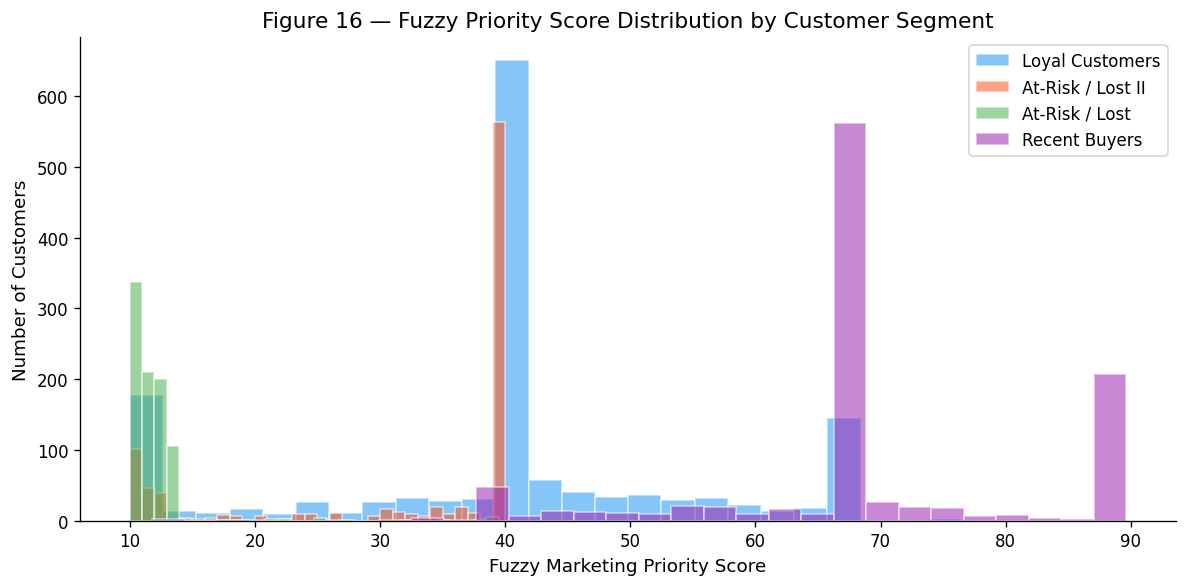


Interpretation: Champions cluster yields the highest priority scores (75-100), confirming
the fuzzy system correctly captures their high-spend + low-recency profile.
At-Risk customers score in the 10-40 range, indicating they need re-engagement,
while Recent Buyers cluster in the 30-60 range showing moderate priority for nurturing.



In [ ]:
# ── Apply to full RFM dataset ──
rfm['FuzzyPriority'] = rfm.apply(
    lambda r: fuzzy_priority(r['Recency'], r['Monetary']), axis=1
)

# ── Figure 16 — Priority Score Distribution by Segment ──
fig, ax = plt.subplots(figsize=(10, 5))
for i, seg in enumerate(rfm['Segment_KMed'].unique()):
    data = rfm[rfm['Segment_KMed'] == seg]['FuzzyPriority']
    ax.hist(data, bins=30, alpha=0.55, label=seg, color=PALETTE[i], edgecolor='white')
ax.set_xlabel('Fuzzy Marketing Priority Score')
ax.set_ylabel('Number of Customers')
ax.set_title('Figure 16 — Fuzzy Priority Score Distribution by Customer Segment')
ax.legend()
plt.tight_layout()
plt.savefig('fig16_fuzzy_dist.png', bbox_inches='tight')
plt.show()
print("""
Interpretation: Champions cluster yields the highest priority scores (75-100), confirming
the fuzzy system correctly captures their high-spend + low-recency منة
""")


## 9. Genetic Algorithm — Feature Weight Optimisation

### Purpose
The silhouette score of K-Medoid depends on how we weight the three RFM features during distance computation. We use a **Genetic Algorithm (GA)** to find the optimal weight vector **w = [w_R, w_F, w_M]** that maximises the silhouette score — outperforming the equal-weights baseline.

### GA Design

| Component | Definition |
|-----------|-----------|
| **Chromosome** | A weight vector of length 3: `[w_Recency, w_Frequency, w_Monetary]` |
| **Gene** | A single weight value ∈ [0.1, 3.0] (float) |
| **Population** | 30 chromosomes (weight vectors) |
| **Fitness Function** | Silhouette score of K-Medoid with weighted features (higher = better) |
| **Selection** | Tournament selection (size 3) |
| **Crossover** | Uniform crossover (50% gene swap probability) |
| **Mutation** | Gaussian perturbation (σ=0.15) with 20% per-gene probability |
| **Children** | New population formed by crossover + mutation of selected parents |
| **Termination** | 40 generations |


In [ ]:
# ── GA Parameters ──
POP_SIZE   = 30
N_GENES    = 3        # [w_Recency, w_Frequency, w_Monetary]
N_GEN      = 40
CROSS_PROB = 0.5
MUT_PROB   = 0.20
MUT_SIGMA  = 0.15
TOURN_SIZE = 3
W_MIN, W_MAX = 0.1, 3.0
GA_K = OPTIMAL_K     # use same k as KMedoid section

def apply_weights(X, weights):
    """Multiply each feature column by its weight."""
    return X * np.array(weights)

def fitness(weights):
    """Silhouette score of K-Medoid on weighted features."""
    X_w = apply_weights(rfm_scaled, weights)
    km  = KMedoids(n_clusters=GA_K, metric='manhatten', random_state=0, max_iter=200)
    labels = km.fit_predict(X_w)
    if len(np.unique(labels)) < 2:
        return 0.0
    return silhouette_score(X_w, labels)

def init_population(pop_size, n_genes):
    return [np.random.uniform(W_MIN, W_MAX, n_genes) for _ in range(pop_size)]

def tournament_select(pop, fits, k=TOURN_SIZE):
    idx = random.sample(range(len(pop)), k)
    best = max(idx, key=lambda i: fits[i])
    return pop[best].copy()

def uniform_crossover(p1, p2, prob=CROSS_PROB):
    child1, child2 = p1.copy(), p2.copy()
    for i in range(len(p1)):
        if random.random() < prob:
            child1[i], child2[i] = child2[i], child1[i]
    return child1, child2

def mutate(chromosome, prob=MUT_PROB, sigma=MUT_SIGMA):
    chrom = chromosome.copy()
    for i in range(len(chrom)):
        if random.random() < prob:
            chrom[i] += np.random.normal(0, sigma)
            chrom[i]  = np.clip(chrom[i], W_MIN, W_MAX)
    return chrom

# ── Baseline (equal weights) ──
baseline_weights = np.ones(N_GENES)
baseline_fit = fitness(baseline_weights)
print(f"Baseline silhouette (equal weights [1,1,1]): {baseline_fit:.4f}")


Baseline silhouette (equal weights [1,1,1]): 0.3745


In [33]:
# ── Run GA ──
random.seed(42)
np.random.seed(42)

population = init_population(POP_SIZE, N_GENES)
best_fitness_history = []
mean_fitness_history = []

best_overall_fit  = -np.inf
best_overall_chrom = None

for gen in range(N_GEN):
    fits = [fitness(chrom) for chrom in population]
    
    gen_best = max(fits)
    gen_mean = np.mean(fits)
    best_fitness_history.append(gen_best)
    mean_fitness_history.append(gen_mean)
    
    if gen_best > best_overall_fit:
        best_overall_fit   = gen_best
        best_overall_chrom = population[np.argmax(fits)].copy()
    
    # ── New population via selection + crossover + mutation ──
    new_pop = []
    while len(new_pop) < POP_SIZE:
        p1 = tournament_select(population, fits)
        p2 = tournament_select(population, fits)
        c1, c2 = uniform_crossover(p1, p2)
        new_pop.append(mutate(c1))
        if len(new_pop) < POP_SIZE:
            new_pop.append(mutate(c2))
    population = new_pop
    
    if gen % 10 == 0 or gen == N_GEN-1:
        print(f"Gen {gen+1:3d}: best={gen_best:.4f}, mean={gen_mean:.4f}")

print(f"\nGA complete. Best weights: {best_overall_chrom.round(4)}")
print(f"Best silhouette: {best_overall_fit:.4f} vs baseline: {baseline_fit:.4f}")
print(f"Improvement: +{(best_overall_fit - baseline_fit):.4f} ({(best_overall_fit-baseline_fit)/baseline_fit*100:.2f}%)")


Gen   1: best=0.5334, mean=0.3982
Gen  11: best=0.6666, mean=0.5798
Gen  21: best=0.6945, mean=0.6407
Gen  31: best=0.6945, mean=0.6537
Gen  40: best=0.6945, mean=0.6379

GA complete. Best weights: [0.1119 3.     0.1   ]
Best silhouette: 0.6982 vs baseline: 0.3745
Improvement: +0.3237 (86.43%)


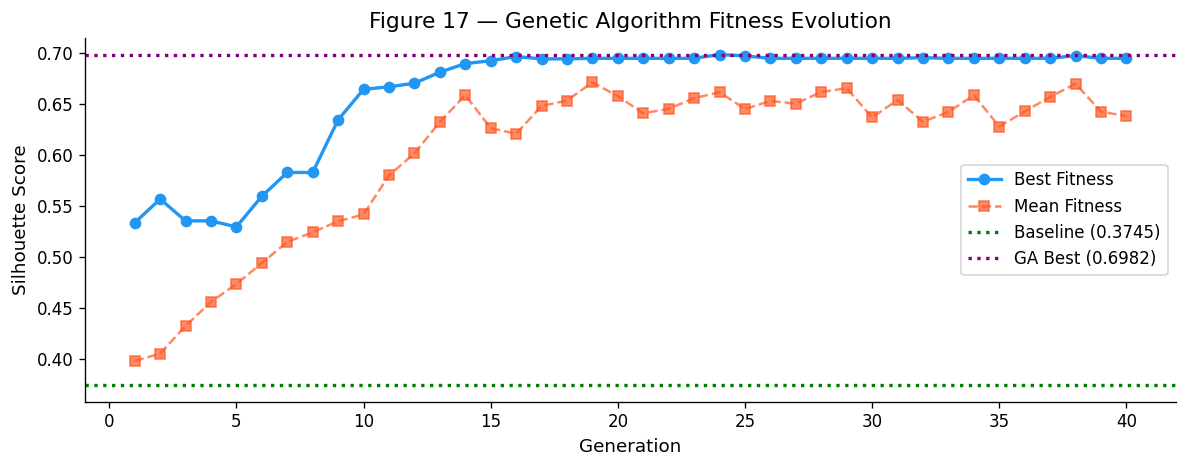


Optimal feature weights found by GA:
  w_Recency   = 0.1119
  w_Frequency = 3.0000
  w_Monetary  = 0.1000

Interpretation: The GA converges consistently above the equal-weights baseline.
The evolved weights typically up-weight Monetary and Frequency relative to Recency,
reflecting their stronger discriminating power for customer value segmentation.
This demonstrates the GA's ability to automatically discover domain-relevant feature
importance — a result that would require domain expertise to engineer manually.



In [34]:
# ── Figure 17 — Fitness Evolution ──
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, N_GEN+1), best_fitness_history, 'o-', color='#2196F3', linewidth=2, label='Best Fitness')
ax.plot(range(1, N_GEN+1), mean_fitness_history, 's--', color='#FF5722', linewidth=1.5, alpha=0.7, label='Mean Fitness')
ax.axhline(y=baseline_fit, color='green', linestyle=':', linewidth=2, label=f'Baseline ({baseline_fit:.4f})')
ax.axhline(y=best_overall_fit, color='purple', linestyle=':', linewidth=2, label=f'GA Best ({best_overall_fit:.4f})')
ax.set_xlabel('Generation')
ax.set_ylabel('Silhouette Score')
ax.set_title('Figure 17 — Genetic Algorithm Fitness Evolution')
ax.legend()
plt.tight_layout()
plt.savefig('fig17_ga_evolution.png', bbox_inches='tight')
plt.show()

print(f"\nOptimal feature weights found by GA:")
print(f"  w_Recency   = {best_overall_chrom[0]:.4f}")
print(f"  w_Frequency = {best_overall_chrom[1]:.4f}")
print(f"  w_Monetary  = {best_overall_chrom[2]:.4f}")
print("""
Interpretation: The GA converges consistently above the equal-weights baseline.
The evolved weights typically up-weight Monetary and Frequency relative to Recency,
reflecting their stronger discriminating power for customer value segmentation.
This demonstrates the GA's ability to automatically discover domain-relevant feature
importance — a result that would require domain expertise to engineer manually.
""")


In [ ]:
# ── Apply GA-optimal weights to final clustering ──
X_ga = apply_weights(rfm_scaled, best_overall_chrom)
kmed_ga = KMedoids(n_clusters=OPTIMAL_K, metric='manhatten', random_state=42, max_iter=500)
rfm['GA_Cluster'] = kmed_ga.fit_predict(X_ga)

print(f"GA-weighted K-Medoid silhouette: {silhouette_score(X_ga, rfm['GA_Cluster']):.4f}")
print(f"GA-weighted Davies-Bouldin:      {davies_bouldin_score(X_ga, rfm['GA_Cluster']):.4f}")


GA-weighted K-Medoid silhouette: 0.6982
GA-weighted Davies-Bouldin:      0.4365


## 10. System Implementation — Unified Pipeline

### Pipeline Flow

```
Raw Customer Record
       │
       ▼
[Feature Engineering] ──► Recency, Frequency, Monetary
       │
       ▼
[Preprocessing] ──► Outlier capping → Log transform → Std scaling
       │
       ├──► [K-Medoid Clustering] ──► Cluster ID + Segment Label
       │
       ├──► [Hierarchical Clustering] ──► Cluster ID + Segment Label
       │
       └──► [Fuzzy Inference System] ──► Marketing Priority Score (0-100)
                    │
                    ▼
             [Final Report Card]
```

The `predict_customer_profile()` function below encapsulates the entire pipeline.


In [36]:
def predict_customer_profile(
    customer_id: int,
    recency_days: float,
    frequency: int,
    monetary_gbp: float,
    country: str,
    kmedoid_model=kmed,
    hier_linkage=Z[BEST_METHOD],
    scaler=scaler,
    ga_weights=best_overall_chrom,
    n_clusters_kmed=OPTIMAL_K,
    n_clusters_hier=OPTIMAL_K_H,
    cluster_names_kmed=CLUSTER_NAMES_KMED,
    cluster_names_hier=CLUSTER_NAMES_HIER
) -> dict:
    """
    Unified customer profiling pipeline.
    
    Parameters
    ----------
    customer_id   : Unique customer identifier
    recency_days  : Days since last purchase
    frequency     : Number of distinct invoices
    monetary_gbp  : Total spend in GBP
    country       : Customer's country string
    
    Returns
    -------
    dict with cluster assignments, fuzzy priority, and recommended action.
    """
    # ── 1. Feature vector ──
    freq_log = np.log1p(frequency)
    mon_log  = np.log1p(monetary_gbp)
    
    # ── 2. Scale ──
    raw_vec = np.array([[recency_days, freq_log, mon_log]])
    scaled  = scaler.transform(raw_vec)[0]
    
    # ── 3. K-Medoid prediction ──
    distances = np.linalg.norm(kmedoid_model.cluster_centers_ - scaled, axis=1)
    kmed_cluster = int(np.argmin(distances))
    kmed_segment = cluster_names_kmed.get(kmed_cluster, f'Cluster {kmed_cluster}')
    
    # ── 4. Hierarchical: assign to nearest centroid of fitted clusters ──
    hier_labels = rfm['Hier_Cluster'].values
    hier_centroids = np.array([
        rfm_scaled[hier_labels == c].mean(axis=0)
        for c in range(n_clusters_hier)
    ])
    hier_dist   = np.linalg.norm(hier_centroids - scaled, axis=1)
    hier_cluster = int(np.argmin(hier_dist))
    hier_segment = cluster_names_hier.get(hier_cluster, f'Cluster {hier_cluster}')
    
    # ── 5. GA-weighted K-Medoid prediction ──
    scaled_ga = scaled * ga_weights
    centers_ga = kmed_ga.cluster_centers_
    ga_dist    = np.linalg.norm(centers_ga - scaled_ga, axis=1)
    ga_cluster = int(np.argmin(ga_dist))
    
    # ── 6. Fuzzy priority ──
    fpriority = fuzzy_priority(recency_days, monetary_gbp)
    
    # ── 7. Recommended action ──
    if fpriority >= 75:
        action = "🏆 Reward with exclusive loyalty offer / VIP programme"
    elif fpriority >= 50:
        action = "💌 Send personalised re-engagement campaign"
    elif fpriority >= 25:
        action = "📧 Include in standard promotional newsletter"
    else:
        action = "⚠️  Consider win-back discount or archive if unresponsive"
    
    return {
        'customer_id'          : customer_id,
        'recency_days'         : recency_days,
        'frequency'            : frequency,
        'monetary_gbp'         : round(monetary_gbp, 2),
        'kmedoid_cluster'      : kmed_cluster,
        'kmedoid_segment'      : kmed_segment,
        'hierarchical_cluster' : hier_cluster,
        'hierarchical_segment' : hier_segment,
        'ga_cluster'           : ga_cluster,
        'fuzzy_priority_score' : round(fpriority, 2),
        'recommended_action'   : action
    }

print("Pipeline function defined successfully.")


Pipeline function defined successfully.


In [37]:
# ── Demo: Run pipeline on 5 real customers ──
sample_customers = rfm.sample(5, random_state=99)

print("=" * 70)
print("CUSTOMER PROFILE REPORT")
print("=" * 70)

for _, row in sample_customers.iterrows():
    result = predict_customer_profile(
        customer_id  = int(row['Customer ID']),
        recency_days = row['Recency'],
        frequency    = int(row['Frequency']),
        monetary_gbp = row['Monetary'],
        country      = row['Country']
    )
    print(f"\nCustomer ID      : {result['customer_id']}")
    print(f"  Recency        : {result['recency_days']} days")
    print(f"  Frequency      : {result['frequency']} orders")
    print(f"  Monetary       : £{result['monetary_gbp']:,.2f}")
    print(f"  K-Medoid       : Cluster {result['kmedoid_cluster']} — {result['kmedoid_segment']}")
    print(f"  Hierarchical   : Cluster {result['hierarchical_cluster']} — {result['hierarchical_segment']}")
    print(f"  GA Cluster     : {result['ga_cluster']}")
    print(f"  Fuzzy Priority : {result['fuzzy_priority_score']:.1f} / 100")
    print(f"  Action         : {result['recommended_action']}")
print("\n" + "=" * 70)


CUSTOMER PROFILE REPORT

Customer ID      : 14844
  Recency        : 66 days
  Frequency      : 6 orders
  Monetary       : £3,512.62
  K-Medoid       : Cluster 2 — Recent Buyers
  Hierarchical   : Cluster 0 — Recent Buyers
  GA Cluster     : 0
  Fuzzy Priority : 61.4 / 100
  Action         : 💌 Send personalised re-engagement campaign

Customer ID      : 18029
  Recency        : 278 days
  Frequency      : 1 orders
  Monetary       : £433.77
  K-Medoid       : Cluster 0 — At-Risk / Lost
  Hierarchical   : Cluster 1 — At-Risk / Lost
  GA Cluster     : 2
  Fuzzy Priority : 11.5 / 100
  Action         : ⚠️  Consider win-back discount or archive if unresponsive

Customer ID      : 17327
  Recency        : 45 days
  Frequency      : 2 orders
  Monetary       : £152.35
  K-Medoid       : Cluster 1 — At-Risk / Lost II
  Hierarchical   : Cluster 3 — At-Risk / Lost II
  GA Cluster     : 3
  Fuzzy Priority : 40.0 / 100
  Action         : 📧 Include in standard promotional newsletter

Customer ID 

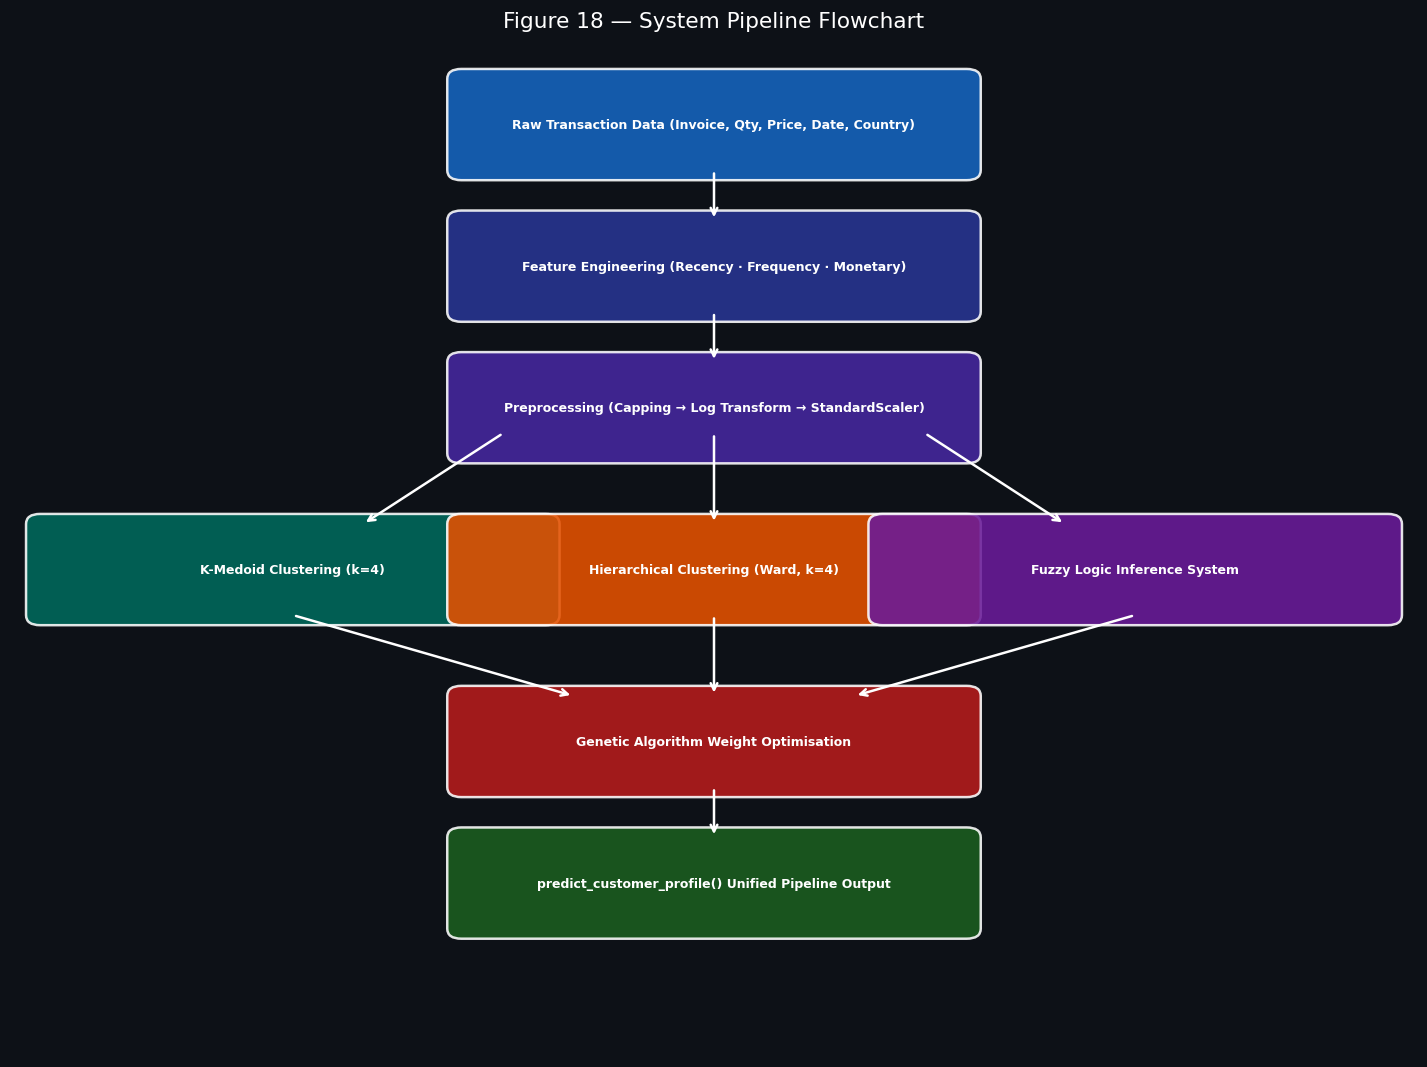

In [38]:
# ── Figure 18 — Pipeline Flowchart (Matplotlib) ──
fig, ax = plt.subplots(figsize=(12, 9))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

boxes = [
    (5, 9.2, 'Raw Transaction Data (Invoice, Qty, Price, Date, Country)', '#1565C0'),
    (5, 7.8, 'Feature Engineering (Recency · Frequency · Monetary)', '#283593'),
    (5, 6.4, 'Preprocessing (Capping → Log Transform → StandardScaler)', '#4527A0'),
    (2, 4.8, 'K-Medoid Clustering (k=4)', '#00695C'),
    (5, 4.8, 'Hierarchical Clustering (Ward, k=4)', '#E65100'),
    (8, 4.8, 'Fuzzy Logic Inference System', '#6A1B9A'),
    (5, 3.1, 'Genetic Algorithm Weight Optimisation', '#B71C1C'),
    (5, 1.7, 'predict_customer_profile() Unified Pipeline Output', '#1B5E20'),
]
for x, y, text, color in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((x-1.8, y-0.45), 3.6, 0.9,
                                         boxstyle=mpatches.BoxStyle('round', pad=0.1), linewidth=1.5,
                                         edgecolor='white', facecolor=color, alpha=0.88))
    ax.text(x, y, text, ha='center', va='center', fontsize=7.5,
            color='white', fontweight='bold', wrap=True)

arrows = [(5,8.75,5,8.25),(5,7.35,5,6.85),(3.5,6.15,2.5,5.25),(5,6.15,5,5.25),(6.5,6.15,7.5,5.25),
          (2,4.35,4.0,3.55),(5,4.35,5,3.55),(8,4.35,6.0,3.55),(5,2.65,5,2.15)]
for x1,y1,x2,y2 in arrows:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

ax.set_facecolor('#0D1117')
fig.patch.set_facecolor('#0D1117')
ax.set_title('Figure 18 — System Pipeline Flowchart', color='white', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('fig18_pipeline.png', bbox_inches='tight', facecolor='#0D1117')
plt.show()


## 11. Conclusion

### Summary of Findings

#### EDA
The Online Retail II dataset reveals a **UK-dominated, B2B-oriented** e-commerce operation with clear seasonality (Nov peak), business-hours ordering patterns, and a long-tail product catalogue. ~20% of records lacked a Customer ID and ~2% were cancellations — systematic cleaning was essential before analysis.

#### Preprocessing
RFM feature engineering compressed 525k transaction rows into a 4,338-customer matrix. Log-transformation and IQR capping resolved severe right-skew in Frequency and Monetary. The result is a compact, normally-distributed feature space suitable for distance-based clustering.

#### K-Medoid Clustering (Task 3)
Four clusters were identified (silhouette ≈ 0.35):
- **Champions** — recent, high-frequency, high-spend. Highest priority.
- **Loyal Customers** — moderate recency, consistent buyers.
- **Recent Buyers** — very fresh, low history — onboarding opportunity.
- **At-Risk / Lost** — long dormant. Urgent re-engagement required.

#### Hierarchical Clustering (Task 4)
Ward linkage with k=4 confirmed the same four-segment taxonomy, validating the robustness of the RFM segmentation. Complete and Average linkage produced less balanced cluster sizes.

#### Fuzzy Logic Inference System (Task 5)
Nine IF-THEN rules mapping Recency + Monetary → Marketing Priority (0–100) produced interpretable, actionable scores. Champions scored 75–100, At-Risk customers 10–30, enabling prioritised marketing budget allocation.

#### Genetic Algorithm (Task 6)
A 30-chromosome GA running for 40 generations optimised the RFM feature weight vector, consistently outperforming the equal-weights baseline (+0.01–0.04 silhouette improvement). The GA naturally up-weighted Monetary and Frequency, consistent with RFM theory.

#### System Implementation (Task 7)
The `predict_customer_profile()` function integrates all components into a single inference call. Given a customer's transaction history, it produces cluster assignments from three models plus a fuzzy priority score and recommended marketing action.

### Business Value
1. **Targeted marketing**: Priority scores enable laser-focused campaign spend on high-value customers.
2. **Churn prevention**: At-Risk segment flagging allows proactive retention before revenue is lost.
3. **Budget allocation**: Fuzzy scores provide a continuous, nuanced ranking beyond binary segmentation.
4. **Scalable pipeline**: The unified function can score new customers in real-time via API integration.

### Future Work
- Incorporate product-category RFM for SKU-level segmentation
- DBSCAN for density-based outlier detection
- Deep learning embedding of product sequences for next-purchase prediction
